In [1]:
from IPython.core.interactiveshell import InteractiveShell
%load_ext autoreload
InteractiveShell.ast_node_interactivity = "all"
import logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [2]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

2025-01-21 15:44:56,467 - numexpr.utils - INFO - Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-01-21 15:44:56,468 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.
/cmnfs/home/z.xiao/miniconda3/envs/sbs/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Summary plot

### Load data

In [3]:
summary_7min_5to30 = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/short_gradient/HeLa/7min_5to30/txt_7min_5to30/summary.txt",
    sep="\t",
)
summary_7min_5to30["Number of MS/MS per MS"] = summary_7min_5to30["Experiment"].str[0]

summary_7min_ref = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/7min_1ug_ref/txt_7min_1ug/summary.txt",
    sep="\t",
)
summary_7min_ref["Number of MS/MS per MS"] = "5"
summary_7min_5to30 = pd.concat(
    [summary_7min_5to30[0:-1], summary_7min_ref[0:-1]], axis=0
)
summary_7min_5to30["LC length"] = "7.5 minutes"

In [4]:
### Summary
summary_15min_5to35 = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/short_gradient/HeLa/15min_5to35/txt_15min_5to35/summary.txt",
    sep="\t",
)
summary_15min_5to35["Number of MS/MS per MS"] = summary_15min_5to35["Experiment"].str[0]
summary_15min_ref = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/15min_2ug_ref/txt_15min_2ug/summary.txt",
    sep="\t",
)
summary_15min_ref["Number of MS/MS per MS"] = "6"
summary_15min_5to35 = pd.concat(
    [summary_15min_5to35.iloc[:-1, :], summary_15min_ref.iloc[:-1, :]], axis=0
)
summary_15min_5to35["LC length"] = "15 minutes"

In [5]:
summary_30min_3to45 = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/short_gradient/HeLa/30min_3to45/txt_30min_3to45/summary.txt",
    sep="\t",
)
summary_30min_3to45["Number of MS/MS per MS"] = summary_30min_3to45["Experiment"].str[0]
summary_30min_ref = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/30min_5ug_ref/txt_30min_5ug/summary.txt",
    sep="\t",
)
summary_30min_ref["Number of MS/MS per MS"] = "7"
summary_30min_3to45 = pd.concat(
    [summary_30min_3to45.iloc[0:9,], summary_30min_ref.iloc[0:-1]], axis=0
)
summary_30min_3to45["LC length"] = "30 minutes"

In [6]:
summary_all = pd.concat(
    [
        summary_15min_5to35,
        summary_7min_5to30,
        summary_30min_3to45,
    ],
    axis=0,
)
summary_exp = pd.read_csv(
    "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/SWAPS_setup_and_gain_of_precursors.csv"
)
summary_exp = pd.merge(
    summary_exp,
    summary_all[
        [
            "Raw file",
            "MS",
            "Peptide sequences identified",
            "Number of MS/MS per MS",
        ]
    ],
    left_on="Raw file name",
    right_on="Raw file",
)
summary_exp_long = pd.melt(
    summary_exp,
    id_vars=[
        "Raw file name",
        "LC Length (min)",
        "Raw file #MSMS/duty cycle (R)",
        "Raw file",
        "MS",
        "Number of MS/MS per MS",
    ],
    value_vars=["120-min library, total", "MaxQuant #ID", "30-min library, total"],
    var_name="Methods",
    value_name="Number of precursors identified",
)

### Plot

In [46]:
import seaborn as sns
from utils.plot import save_plot

plt.figure(figsize=(10, 6))
plt.rc("font", size=22)
ax = sns.scatterplot(
    data=summary_exp_long,
    y="Number of precursors identified",
    x="MS",
    # hue="Number of MS/MS per MS",
    hue="LC Length (min)",
    hue_order=[7.5, 15, 30],
    s=200,
    style="Methods",
    style_order=["MaxQuant #ID", "120-min library, total", "30-min library, total"],
    palette={7.5: "green", 15: "orange", 30: "blue"},
    # hue_order=["1", "2", "3", "5", "6", "7"],
)
# Retrieve the handles and labels from the plot
handles, labels = ax.get_legend_handles_labels()
# Place the legend outside the plot
plt.legend(
    handles=handles,
    labels=labels,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
)
# Set the width of all spines (top, right, bottom, left)
for spine in ax.spines.values():
    spine.set_linewidth(2.0)  # Increase this value for thicker lines
# Optional: you can also make tick marks thicker
ax.tick_params(width=2)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.yticks([0, 20000, 40000, 60000, 80000])
plt.xlabel("MS1 acquired")
plt.ylabel("Precursor Identified")
save_plot(
    save_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application",
    fig_type_name="summary",
    fig_spec_name="SWAPS_setup_and_gain_of_precursors_all_setups",
)

<Figure size 1000x600 with 0 Axes>

(0.0, 9084.3)

(0.0, 78718.85)

([<matplotlib.axis.YTick at 0x7fe25560a4d0>,
 [Text(0, 0, '0'),
  Text(0, 20000, '20000'),
  Text(0, 40000, '40000'),
  Text(0, 60000, '60000'),
  Text(0, 80000, '80000')])

Text(0.5, 0, 'MS1 acquired')

Text(0, 0.5, 'Precursor Identified')

2024-10-29 13:44:29,416 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application/summary_SWAPS_setup_and_gain_of_precursors_all_setups.png
2024-10-29 13:44:29,642 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application/summary_SWAPS_setup_and_gain_of_precursors_all_setups.svg


## Intesnity distribution of exp and ref source

In [4]:
from utils.config import get_cfg_defaults
from utils.singleton_swaps_optimization import swaps_optimization_cfg

fig_save_dir = "/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/"

### 30min

In [4]:
swaps_config_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/30min_3to45_7R_120min_lib_im_ref_20241002_165602_293498/config_20241003_074426_198157.yaml"
ps_dir = "exp_20241003_083433_946837"

cfg = get_cfg_defaults(swaps_optimization_cfg)
cfg.merge_from_file(swaps_config_path)
cfg.PEAK_SELECTION.merge_from_file(
    os.path.join(
        cfg.RESULT_PATH, "peak_selection", ps_dir, "updated_peak_selection_config.yaml"
    )
)
maxquant_result_ref = pd.read_pickle(cfg.DICT_PICKLE_PATH)
# mobility_values_df = pd.read_csv(os.path.join(cfg.RESULT_PATH, "mobility_values.csv"))
# ms1scans = pd.read_csv(os.path.join(cfg.RESULT_PATH, "ms1scans.csv"))
pept_act_sum_ps_full_tdc = pd.read_csv(
    os.path.join(
        cfg.RESULT_PATH,
        "peak_selection",
        ps_dir,
        "pept_act_sum_ps_full_tdc_fdr_thres.csv",
    )
)

In [30]:
%autoreload 2
from result_analysis import result_analysis

swaps_result = result_analysis.SWAPSResult(
    maxquant_dict=maxquant_result_ref,
    pept_act_sum_df=pept_act_sum_ps_full_tdc,
    infer_intensity_col="sum_intensity",
    fdr_thres=0.2,
    log_sum_intensity_thres=2,
    save_dir=os.path.join(fig_save_dir, "fig4_application", "30min_120min"),
    font_size=20,
    title="30-min Exp. with 120-min Ref. Library"
)

swaps_result.plot_intensity_distr(
    title="30-min Exp. with 120-min Ref. Library", x_lim=(1.5, 7.5)
)
swaps_result.plot_intensity_corr(
    show_diag=False,
    title="30-min Exp. with 120-min Ref. Library",
    contour=False,
    font_size=20,
    line_width=2,
)

2024-10-29 13:12:10,016 - result_analysis.result_analysis - INFO - Drop na values in sum_intensity, Pept activation sum entries: 79795
2024-10-29 13:12:10,017 - result_analysis.result_analysis - INFO - Filtering the data by the sum of intensity threshold 2, number of entries before filtering 79795
2024-10-29 13:12:10,025 - result_analysis.result_analysis - INFO - Number of entries after filtering 79795
2024-10-29 13:12:10,028 - result_analysis.result_analysis - INFO - FDR threshold is larger than the maximum FDR, set to maximum FDR 0.161
2024-10-29 13:12:10,029 - result_analysis.result_analysis - INFO - Calculating FDR results after filter...
2024-10-29 13:12:10,033 - peak_detection_2d.utils - INFO - Number of entries before filtering: 79795
2024-10-29 13:12:10,042 - peak_detection_2d.utils - INFO - Number of entries after filtering by log_sum_intensity with condition [0, 100]: 79795
2024-10-29 13:12:16,331 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_fi

### 15min

In [34]:
swaps_config_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/15min_5to35_6R_120min_lib_im_ref_20241002_205908_418520/config_20241002_205908_418520.yaml"
ps_dir = "exp_20241002_223219_829060"

cfg = get_cfg_defaults(swaps_optimization_cfg)
cfg.merge_from_file(swaps_config_path)
cfg.PEAK_SELECTION.merge_from_file(
    os.path.join(
        cfg.RESULT_PATH, "peak_selection", ps_dir, "updated_peak_selection_config.yaml"
    )
)
maxquant_result_ref = pd.read_pickle(cfg.DICT_PICKLE_PATH)
# mobility_values_df = pd.read_csv(os.path.join(cfg.RESULT_PATH, "mobility_values.csv"))
# ms1scans = pd.read_csv(os.path.join(cfg.RESULT_PATH, "ms1scans.csv"))
pept_act_sum_ps_full_tdc = pd.read_csv(
    os.path.join(
        cfg.RESULT_PATH,
        "peak_selection",
        ps_dir,
        "pept_act_sum_ps_full_tdc_fdr_thres.csv",
    )
)

In [36]:
%autoreload 2
from result_analysis import result_analysis
title = "15-min Exp. with 120-min Ref. Library"
swaps_result = result_analysis.SWAPSResult(
    maxquant_dict=maxquant_result_ref,
    pept_act_sum_df=pept_act_sum_ps_full_tdc,
    infer_intensity_col="sum_intensity",
    fdr_thres=0.2,
    log_sum_intensity_thres=2,
    save_dir=os.path.join(fig_save_dir, "fig4_application", "15min_120min"),
    font_size=20,
    title=title
)

swaps_result.plot_intensity_distr(
    title=title, x_lim=(1.5, 7.5)
)
swaps_result.plot_intensity_corr(
    show_diag=False,
    title=title,
    contour=False,
    font_size=20,
    line_width=2,
)

2024-10-29 13:15:34,034 - result_analysis.result_analysis - INFO - Drop na values in sum_intensity, Pept activation sum entries: 70750
2024-10-29 13:15:34,035 - result_analysis.result_analysis - INFO - Filtering the data by the sum of intensity threshold 2, number of entries before filtering 70750
2024-10-29 13:15:34,040 - result_analysis.result_analysis - INFO - Number of entries after filtering 70750
2024-10-29 13:15:34,042 - result_analysis.result_analysis - INFO - Calculating FDR results after filter...
2024-10-29 13:15:34,045 - peak_detection_2d.utils - INFO - Number of entries before filtering: 70750
2024-10-29 13:15:34,050 - peak_detection_2d.utils - INFO - Number of entries after filtering by log_sum_intensity with condition [0, 100]: 70750
2024-10-29 13:15:39,630 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application/15min_120min/fdr_id_targets_result_analysis.png
2024-10-29 13:15:46,455 - utils.plot - INFO - Save plot at /cmnfs/p

### 7.5min

In [5]:
swaps_config_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/7min_5to30_5R_30min_lib_im_ref_20241003_083031_705204/config_20241003_083031_705204.yaml"
ps_dir = "exp_20241003_091422_933050"

cfg = get_cfg_defaults(swaps_optimization_cfg)
cfg.merge_from_file(swaps_config_path)
cfg.PEAK_SELECTION.merge_from_file(
    os.path.join(
        cfg.RESULT_PATH, "peak_selection", ps_dir, "updated_peak_selection_config.yaml"
    )
)
maxquant_result_ref = pd.read_pickle(cfg.DICT_PICKLE_PATH)
# mobility_values_df = pd.read_csv(os.path.join(cfg.RESULT_PATH, "mobility_values.csv"))
# ms1scans = pd.read_csv(os.path.join(cfg.RESULT_PATH, "ms1scans.csv"))
pept_act_sum_ps_full_tdc = pd.read_csv(
    os.path.join(
        cfg.RESULT_PATH,
        "peak_selection",
        ps_dir,
        "pept_act_sum_ps_full_tdc_fdr_thres.csv",
    )
)

In [8]:
%autoreload 2
from result_analysis import result_analysis
title = "7.5-min Exp. with 30-min Ref. Library"
swaps_result = result_analysis.SWAPSResult(
    maxquant_dict=maxquant_result_ref,
    pept_act_sum_df=pept_act_sum_ps_full_tdc,
    infer_intensity_col="sum_intensity",
    fdr_thres=0.2,
    log_sum_intensity_thres=2,
    save_dir=os.path.join(fig_save_dir, "fig4_application", "7min_30min"),
    font_size=20,
    title=title
)


2025-01-21 15:57:42,375 - result_analysis.result_analysis - INFO - Drop na values in sum_intensity, Pept activation sum entries: 41981
2025-01-21 15:57:42,376 - result_analysis.result_analysis - INFO - Filtering the data by the sum of intensity threshold 2, number of entries before filtering 41981
2025-01-21 15:57:42,380 - result_analysis.result_analysis - INFO - Number of entries after filtering 41981
2025-01-21 15:57:42,381 - result_analysis.result_analysis - INFO - FDR threshold is larger than the maximum FDR, set to maximum FDR 0.195
2025-01-21 15:57:42,382 - result_analysis.result_analysis - INFO - Calculating FDR results after filter...
2025-01-21 15:57:42,384 - peak_detection_2d.utils - INFO - Number of entries before filtering: 41981
2025-01-21 15:57:42,388 - peak_detection_2d.utils - INFO - Number of entries after filtering by log_sum_intensity with condition [0, 100]: 41981
2025-01-21 15:57:46,197 - utils.plot - INFO - Save plot at /cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_fi

In [ ]:
swaps_result.plot_intensity_distr(title=title, x_lim=(1.5, 7.5))
swaps_result.plot_intensity_corr(
    show_diag=False,
    title=title,
    contour=False,
    font_size=20,
    line_width=2,
)

# library size for 7.5min (30min or 120min)

In [20]:
from utils.config import get_cfg_defaults
from utils.singleton_swaps_optimization import swaps_optimization_cfg

fig_save_dir = "/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/"
swaps_config_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/7min_5to30_5R_120min_lib_im_ref_20241003_132539_188442/config_20241003_132539_188442.yaml"
ps_dir = "exp_20241003_143020_510644"

cfg = get_cfg_defaults(swaps_optimization_cfg)
cfg.merge_from_file(swaps_config_path)
cfg.PEAK_SELECTION.merge_from_file(
    os.path.join(
        cfg.RESULT_PATH, "peak_selection", ps_dir, "updated_peak_selection_config.yaml"
    )
)
maxquant_result_ref = pd.read_pickle(cfg.DICT_PICKLE_PATH)
# mobility_values_df = pd.read_csv(os.path.join(cfg.RESULT_PATH, "mobility_values.csv"))
# ms1scans = pd.read_csv(os.path.join(cfg.RESULT_PATH, "ms1scans.csv"))
pept_act_sum_ps_full_tdc_120min = pd.read_csv(
    os.path.join(
        cfg.RESULT_PATH,
        "peak_selection",
        ps_dir,
        "pept_act_sum_ps_full_tdc_fdr_thres.csv",
    )
)
pept_act_sum_ps_full_tdc_120min['Library'] = "120-min"
pept_act_sum_ps_full_tdc_30min = pd.read_csv("/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/7min_5to30_5R_30min_lib_im_ref_20241003_083031_705204/peak_selection/exp_20241003_091422_933050/pept_act_sum_ps_full_tdc_fdr_thres.csv")
pept_act_sum_ps_full_tdc_30min['Library'] = "30-min"
pept_act_sum_ps_full_tdc = pd.concat([pept_act_sum_ps_full_tdc_120min, pept_act_sum_ps_full_tdc_30min], axis=0)
%autoreload 2
# from result_analysis import result_analysis
# title = "7.5-min Exp. with 30-min Ref. Library"
# swaps_result = result_analysis.SWAPSResult(
#     maxquant_dict=maxquant_result_ref,
#     pept_act_sum_df=pept_act_sum_ps_full_tdc,
#     infer_intensity_col="sum_intensity",
#     fdr_thres=1,
#     log_sum_intensity_thres=2,
#     save_dir=None,
#     font_size=20,
#     title=title
# )


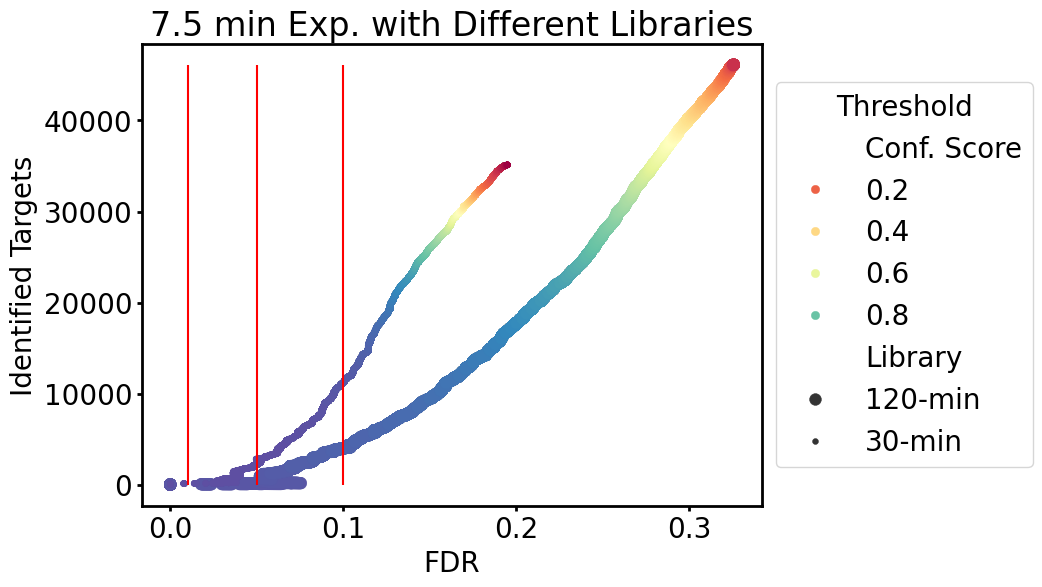

In [22]:
from peak_detection_2d.utils import plot_fdr_and_id

plot_fdr_and_id(
    pred_df_new=pept_act_sum_ps_full_tdc,
    filter_dict=None,
    save_dir=None,
    size="Library",
    title="7.5 min Exp. with Different Libraries",
)

# Intensity distirbution for various R

## 7min_5to30

In [28]:
evidence_7min_5to30 = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/short_gradient/HeLa/7min_5to30/txt_7min_5to30/evidence.txt",
    sep="\t",
)

evidence_7min_5to30["exp_name"] = evidence_7min_5to30["Raw file"].str.extract(
    r"(\dR100ms_R\d)"
)
evidence_7min_5to30_ref = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/7min_1ug_ref/txt_7min_1ug/evidence.txt",
    sep="\t",
)
evidence_7min_5to30_ref["exp_name"] = "5R100ms_" + evidence_7min_5to30_ref[
    "Raw file"
].str.extract(r"(R\d)")
evidence_7min_5to30 = pd.concat([evidence_7min_5to30, evidence_7min_5to30_ref])
evidence_7min_5to30["log_intensity"] = np.log10(evidence_7min_5to30["Intensity"] + 1)
evidence_7min_5to30["exp_name"].value_counts()

/tmp/ipykernel_851473/3074193765.py:1: DtypeWarning: Columns (4,5,62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  evidence_7min_5to30 = pd.read_csv(
/tmp/ipykernel_851473/3074193765.py:9: DtypeWarning: Columns (69) have mixed types. Specify dtype option on import or set low_memory=False.
  evidence_7min_5to30_ref = pd.read_csv(


exp_name
3R100ms_R1    21692
1R100ms_R2    21616
3R100ms_R3    21606
3R100ms_R2    21596
1R100ms_R3    21546
2R100ms_R3    21115
2R100ms_R1    21058
2R100ms_R2    20995
1R100ms_R1    20732
5R100ms_R2    17750
5R100ms_R3    17640
5R100ms_R1    17632
Name: count, dtype: int64

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='exp_name', ylabel='log_intensity'>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '1R100ms_R1'),
  Text(1, 0, '1R100ms_R2'),
  Text(2, 0, '1R100ms_R3'),
  Text(3, 0, '2R100ms_R1'),
  Text(4, 0, '2R100ms_R3'),
  Text(5, 0, '2R100ms_R2'),
  Text(6, 0, '3R100ms_R1'),
  Text(7, 0, '3R100ms_R2'),
  Text(8, 0, '3R100ms_R3'),
  Text(9, 0, '5R100ms_R2'),
  Text(10, 0, '5R100ms_R3'),
  Text(11, 0, '5R100ms_R1')])

Text(0.5, 0, 'Experiment')

Text(0, 0.5, 'MaxQaunt Intensity (Log10)')

Text(0.5, 1.0, '7.5-min LC Gradient')

(2.0, 9.0)

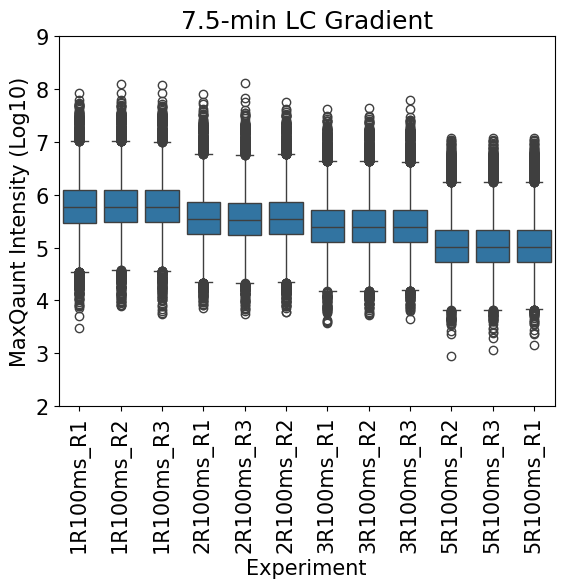

In [47]:
import seaborn as sns

sns.boxplot(
    data=evidence_7min_5to30.loc[evidence_7min_5to30["Type"] == "TIMS-MULTI-MSMS"],
    x="exp_name",
    y="log_intensity",
    order=[
        "1R100ms_R1",
        "1R100ms_R2",
        "1R100ms_R3",
        "2R100ms_R1",
        "2R100ms_R3",
        "2R100ms_R2",
        "3R100ms_R1",
        "3R100ms_R2",
        "3R100ms_R3",
        "5R100ms_R2",
        "5R100ms_R3",
        "5R100ms_R1",
    ],
)
plt.rcParams["font.size"] = 15
plt.xticks(rotation=90)
plt.xlabel("Experiment")
plt.ylabel("MaxQaunt Intensity (Log10)")
plt.title("7.5-min LC Gradient")
plt.ylim(2, 9)
for fig_format in ["svg", "png"]:
    plt.savefig(
        os.path.join(
            "/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application",
            f"SWAPS_7min5to30_MQ_intensity_by_exp.{fig_format}",
        ),
        dpi=300,
        bbox_inches="tight",
    )

## 15 min

In [33]:
evidence_15min_5to35 = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/short_gradient/HeLa/15min_5to35/txt_15min_5to35/evidence.txt",
    sep="\t",
)

evidence_15min_5to35["exp_name"] = evidence_15min_5to35["Raw file"].str.extract(
    r"(\dR100ms_R\d)"
)
evidence_15min_5to35_ref = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/15min_2ug_ref/txt_15min_2ug/evidence.txt",
    sep="\t",
)
evidence_15min_5to35_ref["exp_name"] = "6R100ms_" + evidence_15min_5to35_ref[
    "Raw file"
].str.extract(r"(R\d)")
evidence_15min_5to35 = pd.concat([evidence_15min_5to35, evidence_15min_5to35_ref])
evidence_15min_5to35["log_intensity"] = np.log10(evidence_15min_5to35["Intensity"] + 1)
evidence_15min_5to35["exp_name"].value_counts()

/tmp/ipykernel_851473/751742423.py:1: DtypeWarning: Columns (4,5,62,70) have mixed types. Specify dtype option on import or set low_memory=False.
  evidence_15min_5to35 = pd.read_csv(


exp_name
2R100ms_R3    34923
2R100ms_R2    34893
3R100ms_R1    34789
3R100ms_R2    34522
3R100ms_R3    34493
1R100ms_R2    34416
2R100ms_R1    34296
1R100ms_R3    33484
6R100ms_R2    33405
6R100ms_R3    33209
6R100ms_R1    33147
1R100ms_R1    29570
Name: count, dtype: int64

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='exp_name', ylabel='log_intensity'>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '1R100ms_R1'),
  Text(1, 0, '1R100ms_R2'),
  Text(2, 0, '1R100ms_R3'),
  Text(3, 0, '2R100ms_R1'),
  Text(4, 0, '2R100ms_R3'),
  Text(5, 0, '2R100ms_R2'),
  Text(6, 0, '3R100ms_R1'),
  Text(7, 0, '3R100ms_R2'),
  Text(8, 0, '3R100ms_R3'),
  Text(9, 0, '6R100ms_R2'),
  Text(10, 0, '6R100ms_R3'),
  Text(11, 0, '6R100ms_R1')])

Text(0.5, 0, 'Experiment')

Text(0, 0.5, 'MaxQaunt Intensity (Log10)')

Text(0.5, 1.0, '15-min LC gradient')

(2.0, 9.0)

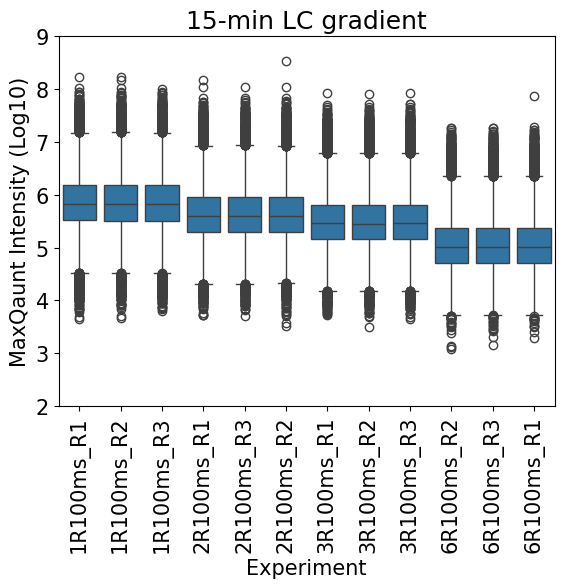

In [45]:
import seaborn as sns

sns.boxplot(
    data=evidence_15min_5to35.loc[evidence_15min_5to35["Type"] == "TIMS-MULTI-MSMS"],
    x="exp_name",
    y="log_intensity",
    order=[
        "1R100ms_R1",
        "1R100ms_R2",
        "1R100ms_R3",
        "2R100ms_R1",
        "2R100ms_R3",
        "2R100ms_R2",
        "3R100ms_R1",
        "3R100ms_R2",
        "3R100ms_R3",
        "6R100ms_R2",
        "6R100ms_R3",
        "6R100ms_R1",
    ],
)
plt.rcParams["font.size"] = 15
plt.xticks(rotation=90)
plt.xlabel("Experiment")
plt.ylabel("MaxQaunt Intensity (Log10)")
plt.title("15-min LC gradient")
plt.ylim(2, 9)
for fig_format in ["svg", "png"]:
    plt.savefig(
        os.path.join(
            "/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application",
            f"SWAPS_15min5to35_MQ_intensity_by_exp.{fig_format}",
        ),
        dpi=300,
        bbox_inches="tight",
    )

## 30 min

In [39]:
evidence_30min_3to45 = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/short_gradient/HeLa/30min_3to45/txt_30min_3to45/evidence.txt",
    sep="\t",
)

evidence_30min_3to45["exp_name"] = evidence_30min_3to45["Raw file"].str.extract(
    r"(\dR100ms_R\d)"
)
evidence_30min_3to45_ref = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/30min_5ug_ref/txt_30min_5ug/evidence.txt",
    sep="\t",
)
evidence_30min_3to45_ref["exp_name"] = "7R100ms_" + evidence_30min_3to45_ref[
    "Raw file"
].str.extract(r"(R\d)")
evidence_30min_3to45 = pd.concat([evidence_30min_3to45, evidence_30min_3to45_ref])
evidence_30min_3to45["log_intensity"] = np.log10(evidence_30min_3to45["Intensity"] + 1)
evidence_30min_3to45["exp_name"].value_counts()

/tmp/ipykernel_851473/544960836.py:1: DtypeWarning: Columns (62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  evidence_30min_3to45 = pd.read_csv(
/tmp/ipykernel_851473/544960836.py:9: DtypeWarning: Columns (61) have mixed types. Specify dtype option on import or set low_memory=False.
  evidence_30min_3to45_ref = pd.read_csv(


exp_name
1R100ms_R1    61495
1R100ms_R2    60433
1R100ms_R3    59627
2R100ms_R3    56777
2R100ms_R2    56086
3R100ms_R2    55133
3R100ms_R1    54886
3R100ms_R3    54848
2R100ms_R1    54066
7R100ms_R3    52785
7R100ms_R2    52678
7R100ms_R1    52515
Name: count, dtype: int64

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='exp_name', ylabel='log_intensity'>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '1R100ms_R1'),
  Text(1, 0, '1R100ms_R2'),
  Text(2, 0, '1R100ms_R3'),
  Text(3, 0, '2R100ms_R1'),
  Text(4, 0, '2R100ms_R3'),
  Text(5, 0, '2R100ms_R2'),
  Text(6, 0, '3R100ms_R1'),
  Text(7, 0, '3R100ms_R2'),
  Text(8, 0, '3R100ms_R3'),
  Text(9, 0, '7R100ms_R2'),
  Text(10, 0, '7R100ms_R3'),
  Text(11, 0, '7R100ms_R1')])

Text(0.5, 0, 'Experiment')

Text(0, 0.5, 'MaxQaunt Intensity (Log10)')

Text(0.5, 1.0, '30-min LC gradient')

(2.0, 9.0)

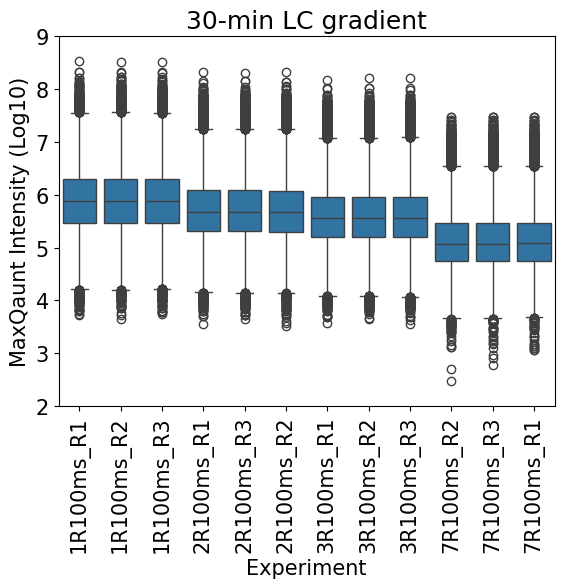

In [44]:
import seaborn as sns

sns.boxplot(
    data=evidence_30min_3to45.loc[evidence_30min_3to45["Type"] == "TIMS-MULTI-MSMS"],
    x="exp_name",
    y="log_intensity",
    order=[
        "1R100ms_R1",
        "1R100ms_R2",
        "1R100ms_R3",
        "2R100ms_R1",
        "2R100ms_R3",
        "2R100ms_R2",
        "3R100ms_R1",
        "3R100ms_R2",
        "3R100ms_R3",
        "7R100ms_R2",
        "7R100ms_R3",
        "7R100ms_R1",
    ],
)
plt.rcParams["font.size"] = 15
plt.xticks(rotation=90)
plt.xlabel("Experiment")
plt.ylabel("MaxQaunt Intensity (Log10)")
plt.title("30-min LC gradient")
plt.ylim(2, 9)
for fig_format in ["svg", "png"]:
    plt.savefig(
        os.path.join(
            "/cmnfs/proj/ORIGINS/SWAPS_exp/SWAPS_paper_figures/fig4_application",
            f"SWAPS_30min_3to45_MQ_intensity_by_exp.{fig_format}",
        ),
        dpi=300,
        bbox_inches="tight",
    )